In [1]:
import os
import torch
import pandas as pd
import scanpy as sc
from preprocess import *
from utils import *
import numpy as np
import matplotlib.pyplot as plt
import harmonypy as hm

from train import Train

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [3]:
# savepath = 'Result'
# if not os.path.exists(savepath):
#     os.mkdir(savepath)

In [4]:
def mapping2int(string_array):
    mapping = {}
    result = []
    for string in string_array:
        if string not in mapping:
            mapping[string] = len(mapping)
        result.append(mapping[string])
    return result, mapping

import anndata as ad

#load data
count = pd.read_csv(
        "../../../data/Mouse_Brain/GSE147747/GSE147747_expr_raw_counts_table.tsv",
        sep="\t", index_col=0)
meta = pd.read_csv("../../../data/Mouse_Brain/GSE147747/GSE147747_meta_table.tsv",
                       sep="\t",
                       index_col=0)

In [5]:
adata_st_all = ad.AnnData(X=count.values)
adata_st_all.obs.index = count.index
adata_st_all.obs = meta.loc[adata_st_all.obs.index]
adata_st_all.var.index = count.columns

slice_use = ['01A', '02A', '03A', '04B', '05A', '06B', '07A', '08B', '09A', '10B',
                 '11A', '12A', '13B', '14A', '15A', '16A', '17A', '18A', '19A', '20B',
                 '21A', '22A', '23A', '24A', '25A', '26A', '27A', '28A', '29A', '30A',
                 '31A', '32A', '33A', '34A', '35A', ]


result, mapping = mapping2int(slice_use)

adata_st_all = adata_st_all[[s in slice_use for s in adata_st_all.obs.section_index.values]]
sc.pp.filter_cells(adata_st_all, min_genes=1)

D:\anaconda\envs\njy\Lib\site-packages\scanpy\preprocessing\_simple.py:160: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_genes"] = number


In [8]:
adata_list = []

for i, slice_id in enumerate(sorted(set(adata_st_all.obs.section_index.values))):
        adata_tmp = adata_st_all[adata_st_all.obs.section_index.values == slice_id]
        array_col = np.array([np.float32(loc.split("_")[1].split("x")[0]) for loc in adata_tmp.obs.index])
        if slice_id == '01A':
            array_col = array_col - 0.3
        array_row = np.array([np.float32(loc.split("_")[1].split("x")[1]) for loc in adata_tmp.obs.index])
        
        adata_tmp.obs['array_col'] = np.round(array_col)
        adata_tmp.obs['array_row'] = np.round(array_row)

        adata_tmp.obs['batch_name'] = slice_id
        adata_tmp.obs['slice_id'] = mapping[slice_id]
        
        df = pd.DataFrame()
        df.loc[:,0] = adata_tmp.obs['array_col']
        df.loc[:,1] = adata_tmp.obs['array_row']
        adata_tmp.obsm['spatial'] = df
        
        adata_tmp.var_names_make_unique()
        
        # Remove mt-genes
        adata_tmp = adata_tmp[:, (np.array(~adata_tmp.var.index.str.startswith("mt-"))
                                  & np.array(~adata_tmp.var.index.str.startswith("MT-")))]
        adata_tmp.obs.index = adata_tmp.obs.index + "-slice%d" % i

        adata_tmp = adata_tmp[~pd.isnull(adata_tmp.obs['ABA_parent'])]
        
        adata_tmp.obs_names = [x + '_' + slice_id for x in adata_tmp.obs_names]
        adata_tmp.obs['batch_name'] = [slice_id] * adata_tmp.X.shape[0]
        adata_list.append(adata_tmp)

C:\Users\DELL\AppData\Local\Temp\ipykernel_204676\1915754141.py:10: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_tmp.obs['array_col'] = np.round(array_col)
C:\Users\DELL\AppData\Local\Temp\ipykernel_204676\1915754141.py:10: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_tmp.obs['array_col'] = np.round(array_col)
C:\Users\DELL\AppData\Local\Temp\ipykernel_204676\1915754141.py:10: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_tmp.obs['array_col'] = np.round(array_col)
C:\Users\DELL\AppData\Local\Temp\ipykernel_204676\1915754141.py:10: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_tmp.obs['array_col'] = np.round(array_col)
C:\Users\DELL\AppData\Local\Temp\ipykernel_204676\1915754141.py:10: ImplicitModificationWarning: Trying to modify attrib

In [9]:
epochs = 500
coord_type = 'spatial'
weights = [[60, 0.01, 0.01]]

n_neighbor = 5
n_cluster = 15 

batch_adata = integrate_adata(adata_list, coord_type=coord_type, n_neighbor=n_neighbor)

Recommended l is 2
Recommended l is 2
Recommended l is 2
Recommended l is 2
Recommended l is 2
Recommended l is 2
Recommended l is 2
Recommended l is 2
Recommended l is 2
Recommended l is 2
Recommended l is 2
Recommended l is 2
Recommended l is 2
Recommended l is 2
Recommended l is 2
Recommended l is 2
Recommended l is 2
Recommended l is 2
Recommended l is 2
Recommended l is 2
Recommended l is 2
Recommended l is 2
Recommended l is 2
Recommended l is 2
Recommended l is 2
Recommended l is 2
Recommended l is 2
Recommended l is 2
Recommended l is 2
Recommended l is 2
Recommended l is 2
Recommended l is 2
Recommended l is 2
Recommended l is 2
Recommended l is 2
AnnData object with n_obs × n_vars = 17086 × 18995
    obs: 'section_index', 'stereo_ML', 'stereo_DV', 'stereo_AP', 'HE_X', 'HE_Y', 'ABA_acronym', 'ABA_name', 'ABA_parent', 'nuclei_segmented', 'spot_radius', 'passed_QC', 'cluster_id', 'cluster_name', 'n_genes', 'array_col', 'array_row', 'batch_name', 'slice_id'
    var: 'n_cells', 'h

In [10]:
for mse_weight, graph_weight, nce_weight in weights:
    # set = batch_tag + "_" + str(n_neighbor) + "_" + str(mse_weight) + "_" + str(graph_weight) \
    #     + "_" + str(nce_weight) + "_" + str(epochs)
    # print(set)
    print("*" * 70)
    
    model = Train(batch_adata, device=device, epochs=epochs, mse_weight=mse_weight,
                      graph_weight=graph_weight, nce_weight=nce_weight, coord_type=coord_type,
                      n_neighbor=n_neighbor, n_cluster=n_cluster, protocol='10X')
    batch_adata = model.train()

    # Harmony
    data_mat = batch_adata.obsm['emb'].copy()
    vars_use = ['batch_name']
    meta_data = batch_adata.obs[vars_use]
    # Run Harmony
    ho = hm.run_harmony(data_mat, meta_data, vars_use)
    batch_adata.obsm['Harmony_Revised'] = ho.Z_corr.T

    method = 'mclust'  # mclust, leiden, louvain, kmeans
    cluster(batch_adata, n_clusters=n_cluster, method=method, key='Harmony_Revised')

    domain_tag = 'domain'
    embed_tag = 'Harmony_Revised'

    # filter out NA nodes
    # sub_adata = batch_adata[~pd.isnull(batch_adata.obs['ground_truth'])]

    # sc.set_figure_params(vector_friendly=True, figsize=(4.5 / 2.54, 4.5 / 2.54))
    # fig, ax_list = plt.subplots(1, 4, figsize=(5 / 2.54 * 4, 5 / 2.54))
    # ### Plotting UMAP before batch effect correction
    # sc.pp.pca(sub_adata)
    # sc.pp.neighbors(sub_adata, use_rep='X_pca')
    # sc.tl.umap(sub_adata)
    # sc.pl.umap(sub_adata, color='batch_name', title='Uncorrected', ax=ax_list[0], frameon=False,
    #            show=False, size=3, legend_fontsize=5)
    # ### Plotting UMAP after batch effect correction
    # sc.pp.neighbors(sub_adata, use_rep=embed_tag)
    # sc.tl.umap(sub_adata)
    # sc.pl.umap(sub_adata, color='batch_name', ax=ax_list[1], title='Batch corrected', frameon=False,
    #            show=False, size=3, legend_fontsize=5)
    # 
    # sc.pl.umap(sub_adata, color='ground_truth', ax=ax_list[2], title='Ground Truth', frameon=False,
    #            show=False, size=3, legend_fontsize=5)
    # sc.pl.umap(sub_adata, color=domain_tag, ax=ax_list[3], title='Predict Domain', frameon=False,
    #            show=False, size=3, legend_fontsize=5)
    # plt.savefig(savepath + f'SpaGIC_{batch_tag}_umap_hm.png', bbox_inches='tight', dpi=300)
    # # plt.savefig(savepath + f'SpaGIC_{batch_tag}_umap_hm.pdf', bbox_inches='tight', dpi=300)
    # # plt.show()
    # plt.close()

    # scores
    # ARI = adjusted_rand_score(sub_adata.obs['ground_truth'], sub_adata.obs[domain_tag])
    # NMI = normalized_mutual_info_score(sub_adata.obs['ground_truth'], sub_adata.obs[domain_tag])
    # print(f'{batch_tag}, ARI: {ARI}; NMI: {NMI}')

    #### single slice visual
    # sc.set_figure_params(vector_friendly=True, figsize=(3.2 / 2.54, 3.5 / 2.54))
    # fig, axs = plt.subplots(1, len(datasets), figsize=(4.5 * len(datasets), 3))
    # for idx, single_adata in enumerate(adata_list):
    #     single_adata.obs[domain_tag] = batch_adata[batch_adata.obs['batch_name'] == datasets[idx]].obs[domain_tag].values
    #     # filter out NA nodes
    #     sub_adata = single_adata[~pd.isnull(single_adata.obs['ground_truth'])]
    #     refine(sub_adata, radius=50, key=domain_tag)
    #     key = 'domain_refined'
    #     ARI = adjusted_rand_score(sub_adata.obs['ground_truth'], sub_adata.obs[key])
    #     NMI = normalized_mutual_info_score(sub_adata.obs['ground_truth'], sub_adata.obs[key])
    #     print(f'{datasets[idx]}, ARI: {ARI}; NMI: {NMI}')
    #     sc.pl.spatial(sub_adata, img_key="hires", ax=axs[idx], color=key, frameon=False, legend_fontsize=8,
    #                   title=f'{datasets[idx]}_ARI=%.4f-NMI=%.4f' % (ARI, NMI), show=False)
    # plt.savefig(savepath + f'SpaGIC_{batch_tag}_sp_hm.png', bbox_inches='tight', dpi=300)
    # plt.savefig(savepath + f'SpaGIC_{batch_tag}_sp_hm.pdf', bbox_inches='tight', dpi=300)
    # plt.show()
    # plt.close()

**********************************************************************
Begin to train...


100%|██████████| 500/500 [02:31<00:00,  3.30it/s]


Optimization finished!


2024-12-31 12:34:10,512 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2024-12-31 12:34:13,441 - harmonypy - INFO - sklearn.KMeans initialization complete.
2024-12-31 12:34:13,528 - harmonypy - INFO - Iteration 1 of 10
2024-12-31 12:34:18,339 - harmonypy - INFO - Iteration 2 of 10
2024-12-31 12:34:23,339 - harmonypy - INFO - Iteration 3 of 10
2024-12-31 12:34:28,235 - harmonypy - INFO - Iteration 4 of 10
2024-12-31 12:34:33,288 - harmonypy - INFO - Iteration 5 of 10
2024-12-31 12:34:38,189 - harmonypy - INFO - Iteration 6 of 10
2024-12-31 12:34:43,181 - harmonypy - INFO - Iteration 7 of 10
2024-12-31 12:34:48,187 - harmonypy - INFO - Iteration 8 of 10
2024-12-31 12:34:53,038 - harmonypy - INFO - Converged after 8 iterations


clustering...


R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.0.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


In [11]:
batch_adata.write('SpaGIC_MOE.h5ad')

TypeError: 0 of type <class 'int'> is an invalid key. Should be str.

In [12]:
batch_adata

AnnData object with n_obs × n_vars = 17086 × 18995
    obs: 'section_index', 'stereo_ML', 'stereo_DV', 'stereo_AP', 'HE_X', 'HE_Y', 'ABA_acronym', 'ABA_name', 'ABA_parent', 'nuclei_segmented', 'spot_radius', 'passed_QC', 'cluster_id', 'cluster_name', 'n_genes', 'array_col', 'array_row', 'batch_name', 'slice_id', 'mclust', 'domain'
    var: 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'hvg', 'log1p'
    obsm: 'spatial', 'neighbors', 'feature', 'emb', 'rec_feat', 'Harmony_Revised'
    obsp: 'adj'

In [13]:
from sklearn.metrics import adjusted_rand_score as ari_score
from sklearn.metrics import normalized_mutual_info_score as nmi_score
from sklearn.metrics import adjusted_mutual_info_score as ami_score
from sklearn.metrics import homogeneity_score as hom_score
from sklearn.metrics import completeness_score as com_score

In [17]:
sub_adata = batch_adata[~pd.isnull(batch_adata.obs['ABA_parent'])]
ARI = ari_score(sub_adata.obs['ABA_parent'], sub_adata.obs['mclust'])
print(f"total ARI:{ARI}")
ARI_list = []
for name in slice_use:
    sub_adata_tmp = sub_adata[sub_adata.obs['batch_name'] == name]
    ARI = ari_score(sub_adata_tmp.obs['ABA_parent'], sub_adata_tmp.obs['mclust'])
    print(f"{name} ARI:{ARI}")
    ARI_list.append(ARI)
print('Mean:',np.mean(ARI_list))
print('Median:',np.median(ARI_list))

total ARI:0.34478651869146265
01A ARI:0.38467475137085894
02A ARI:0.32199511294848576
03A ARI:0.23589119433070008
04B ARI:0.22998919582558816
05A ARI:0.3032108322059123
06B ARI:0.3922584157980619
07A ARI:0.38807264173377254
08B ARI:0.4403000224741708
09A ARI:0.4796638894660546
10B ARI:0.4272413981339349
11A ARI:0.41922292365116326
12A ARI:0.42697445744587914
13B ARI:0.4100693956458791
14A ARI:0.43872178315895377
15A ARI:0.3985769566805136
16A ARI:0.3968686777020942
17A ARI:0.4412269365632785
18A ARI:0.4306923687593641
19A ARI:0.4552405364090625
20B ARI:0.46868845306036794
21A ARI:0.45843258524243546
22A ARI:0.4201207789484664
23A ARI:0.41539709071482517
24A ARI:0.42301787249773676
25A ARI:0.3338412387832266
26A ARI:0.3639429968272034
27A ARI:0.3768906432010159
28A ARI:0.31973315545889686
29A ARI:0.36636941404950557
30A ARI:0.3343233120508651
31A ARI:0.28841886899635083
32A ARI:0.2570785193764
33A ARI:0.28767344408228096
34A ARI:0.31040791176011495
35A ARI:0.3035748368669781
Mean: 0.375

In [14]:
sub_adata = batch_adata[~pd.isnull(batch_adata.obs['ABA_parent'])]
NMI = nmi_score(sub_adata.obs['ABA_parent'], sub_adata.obs['mclust'])
print(f"total NMI:{NMI}")
AMI = ami_score(sub_adata.obs['ABA_parent'], sub_adata.obs['mclust'])
print(f"total AMI:{AMI}")
NMI_list = []
AMI_list = []
for name in slice_use:
    sub_adata_tmp = sub_adata[sub_adata.obs['batch_name'] == name]
    NMI = nmi_score(sub_adata_tmp.obs['ABA_parent'], sub_adata_tmp.obs['mclust'])
    AMI = ami_score(sub_adata_tmp.obs['ABA_parent'], sub_adata_tmp.obs['mclust'])
    ACC = 1/2 * (NMI + AMI)
    print(f"{name} ACC:{ACC}")
    NMI_list.append(NMI)
    AMI_list.append(AMI)
print('NMI Mean:',np.mean(NMI_list))
print('NMI Median:',np.median(NMI_list))
print('AMI Mean:',np.mean(AMI_list))
print('AMI Median:',np.median(AMI_list))

total NMI:0.5200267967371889
total AMI:0.5188692945224341
01A ACC:0.4319813504331915
02A ACC:0.4446047933150914
03A ACC:0.41157755305509036
04B ACC:0.4015244638359339
05A ACC:0.4850686604918367
06B ACC:0.5114353236971985
07A ACC:0.505001642017032
08B ACC:0.580307803235006
09A ACC:0.5907111486181305
10B ACC:0.5745066932598317
11A ACC:0.5381395884961392
12A ACC:0.6064450677358492
13B ACC:0.6066862961763158
14A ACC:0.6122966763578368
15A ACC:0.5800559897242799
16A ACC:0.5924168615597776
17A ACC:0.6153934356838879
18A ACC:0.6195440703114474
19A ACC:0.6253226098943776
20B ACC:0.6459110071322742
21A ACC:0.6427900638539072
22A ACC:0.6205156431674733
23A ACC:0.6143442211670531
24A ACC:0.6184747485000854
25A ACC:0.5149224169980837
26A ACC:0.5548833248398346
27A ACC:0.5757174081043415
28A ACC:0.5506362095181991
29A ACC:0.5658965664768071
30A ACC:0.5064818596441037
31A ACC:0.4897947039972211
32A ACC:0.46056443005624026
33A ACC:0.44965757511227344
34A ACC:0.4776775423977624
35A ACC:0.4880133918446

In [15]:
sub_adata = batch_adata[~pd.isnull(batch_adata.obs['ABA_parent'])]
HOM = hom_score(sub_adata.obs['ABA_parent'], sub_adata.obs['mclust'])
print(f"total HOM:{HOM}")
COM = com_score(sub_adata.obs['ABA_parent'], sub_adata.obs['mclust'])
print(f"total COM:{COM}")
V_list = []
for name in slice_use:
    sub_adata_tmp = sub_adata[sub_adata.obs['batch_name'] == name]
    HOM = hom_score(sub_adata_tmp.obs['ABA_parent'], sub_adata_tmp.obs['mclust'])
    COM = com_score(sub_adata_tmp.obs['ABA_parent'], sub_adata_tmp.obs['mclust'])
    V =  2 * ((HOM * COM) / (HOM + COM))
    print(f"{name} V:{V}")
    V_list.append(V)
print('V Mean:',np.mean(V_list))
print('V Median:',np.median(V_list))

total HOM:0.5639937768939304
total COM:0.4824190932991656
01A V:0.44201789477692816
02A V:0.4499206288673217
03A V:0.4245492501264444
04B V:0.4141954646133941
05A V:0.49816245324128466
06B V:0.5243734616882205
07A V:0.5164205550667584
08B V:0.5910610173384332
09A V:0.6001860701449246
10B V:0.5840879643502175
11A V:0.5504314530178739
12A V:0.6173737375907838
13B V:0.6165057093712669
14A V:0.6229023876107802
15A V:0.5919385597430635
16A V:0.6045757076107268
17A V:0.62608215595981
18A V:0.6306103667908147
19A V:0.6358961773900044
20B V:0.6575709059999243
21A V:0.6521839429005846
22A V:0.630885644918619
23A V:0.6255082542382485
24A V:0.6295330681509158
25A V:0.5297701133755729
26A V:0.5672806481698236
27A V:0.5860566151668858
28A V:0.5605258206020466
29A V:0.575649782427273
30A V:0.5167778538204872
31A V:0.4991571068561357
32A V:0.47015288616865486
33A V:0.4566452222820173
34A V:0.4848325485872588
35A V:0.4978783116048899
V Mean: 0.5566199925876683
V Median: 0.575649782427273


3.660136974416148
1.2572281682587259


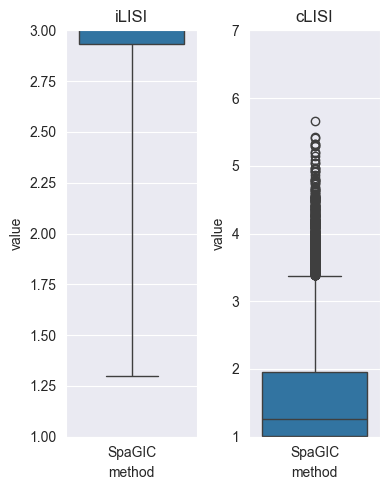

In [16]:
import harmonypy as hm

iLISI = hm.compute_lisi(batch_adata.obsm['Harmony_Revised'], batch_adata.obs[['batch_name']], label_colnames=['batch_name'])[:, 0]
cLISI = hm.compute_lisi(batch_adata.obsm['Harmony_Revised'], batch_adata.obs[['ABA_parent']], label_colnames=['ABA_parent'])[:, 0]

df_iLISI = pd.DataFrame({
    'method': 'SpaGIC',
    'value': iLISI,
    'type': ['ILISI'] * len(iLISI)
})

df_cLISI = pd.DataFrame({
    'method': 'SpaGIC',
    'value': cLISI,
    'type': ['CLISI'] * len(cLISI)
})

fig, axes = plt.subplots(1, 2, figsize=(4, 5))
sns.boxplot(data=df_iLISI, x='method', y='value', ax=axes[0])
sns.boxplot(data=df_cLISI, x='method', y='value', ax=axes[1])
axes[0].set_ylim(1, 3)
axes[1].set_ylim(1, 7)
axes[0].set_title('iLISI')
axes[1].set_title('cLISI')

plt.tight_layout()
print(np.median(iLISI))
print(np.median(cLISI))

In [4]:
adata = sc.read_h5ad('SpaGIC_MOE.h5ad')

AttributeError: 'dict' object has no attribute 'shape'